# Linear Regression (LMS) and Batch Gradient Descent

**Linear Regression** is a **supervised machine learning** algorithm used to predict a continuous numerical output.

*   **The Data:** We use a training set consisting of input **features** ($x$) and corresponding correct output **targets** ($y$).
*   **The Model:** The algorithm fits a straight line to the data using the linear function: 
    $$f_{w,b}(x) = wx + b$$
*   **The Parameters:** The variables **$w$ (weight)** and **$b$ (bias)** are the learnable parameters.
*   **The Objective:** We train the model to find the optimal values for $w$ and $b$ so that the function predicts values as close as possible to the actual targets in our training set.

**The Cost Function: Measuring Model Accuracy**

To train our model, we first need a mathematical way to measure how well (or poorly) it is currently predicting the data. We do this by calculating the total error between our model's predictions and the actual true targets.

*   **The Squared Error Cost Function:** This is the standard cost function used for linear regression. It is written mathematically as:
    $$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

*   **Breaking Down the Equation:**
    *   **$J(w,b)$**: The cost function. It evaluates how good a specific set of parameters ($w$ and $b$) are.
    *   **$m$**: The total number of training examples in our dataset.
    *   **$f_{w,b}(x^{(i)})$**: Our model's prediction for the $i$-th example.
    *   **$y^{(i)}$**: The actual, true target value for the $i$-th example.
    *   **Why square the error?** Squaring the difference $(prediction - target)$ does two things. First, it makes all errors positive, ensuring that a prediction that is too high doesn't cancel out a prediction that is too low. Second, it heavily penalizes predictions that are very far off from the true target.
    *   **Why divide by $2m$?** Dividing by $m$ computes the average (mean) error across the entire dataset. We divide by $2$ purely to make the calculus cleaner later; when we take the derivative of the squared error, the exponent $2$ comes down and neatly cancels out the $\frac{1}{2}$.


**Gradient Descent: The Optimization Algorithm**

If we plot the Cost Function $J(w,b)$ for linear regression, it always forms a perfect 3D convex shape (like a soup bowl). Our goal is to find the exact values of $w$ and $b$ that put us at the very bottom of that bowl, where the error is minimized. 

*   **The Intuition:** Imagine standing high up on a mountain while blindfolded. we spin around 360 degrees, feel the terrain with our feet to find the steepest direction pointing downhill, and take a small step. we repeat this process over and over until we reach the flat valley floor (the global minimum).

*   **The Algorithm:** Gradient descent mathematically updates our parameters by taking their current value and subtracting the derivative (the slope of the bowl at your current position):
    $$w = w - \alpha \frac{\partial J(w,b)}{\partial w}$$
    $$b = b - \alpha \frac{\partial J(w,b)}{\partial b}$$

*   **Simultaneous Update (Crucial Concept):** When implementing this in code, $w$ and $b$ must be updated **simultaneously**. We must compute the right side of both equations using your *old* parameters, store those results in temporary variables, and only then update the actual $w$ and $b$ variables. If we update $w$ first and then use the *new* $w$ to calculate the update for $b$, the algorithm will not work correctly.


**The Learning Rate ($\alpha$)**

The variable $\alpha$ (alpha) is the **learning rate**. It acts as a multiplier that determines exactly how large of a "step" we take downhill during each iteration.

*   **If $\alpha$ is too small:** Gradient descent will correctly find the minimum, but it will take an incredibly large number of tiny baby steps to get there. The algorithm will be very reliable but painfully slow.
*   **If $\alpha$ is too large:** The steps are so massive that the model overshoots the bottom of the bowl. It will step to the other side of the curve, moving higher and further away from the minimum with each iteration. The algorithm **diverges** and fails to learn.

**Gradient Descent for Linear Regression: The Math**

To make our algorithm learn, we must compute the exact partial derivatives of our squared error cost function. This tells our model the steepness and direction of the slope at our current position, allowing us to step closer to the minimum error.

1. A Simple Training Set Example

To understand how the math processes data, let us use a miniature training set containing just two examples of housing prices.

| $i$ (Index) | Input Feature: Size in 1000 sqft ($x^{(i)}$) | Target Output: Price in $1000s ($y^{(i)}$) |
| :--- | :--- | :--- |
| 0 | 1.0 | 300.0 |
| 1 | 2.0 | 500.0 |

*   **$m$ (Total Examples):** In this dataset, $m = 2$.
*   **Indexing:** To access the first house's size, we use $x^{(0)} = 1.0$, and its corresponding price is $y^{(0)} = 300.0$.


2. The Derivative Equations

By applying calculus to our cost function $J(w,b)$, we get two specific formulas for the gradients. We compute these gradients over the entire training set.

**The Gradient for $w$:**
$$\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)}$$

**The Gradient for $b$:**
$$\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})$$


3. Why Do These Formulas Make Sense?


*   **The Error Term:** In both equations, the term $(f_{w,b}(x^{(i)}) - y^{(i)})$ is simply our **Error**. It is the difference between what our model predicted and the actual true price. 
    *   If the model predicts exactly $300$ for the first house, the error is $0$.
    *   If the model predicts $400$, the error is $+100$.

*   **The Update for Bias ($b$):** The gradient for $b$ is just the **average of all the errors**. If our model is consistently over-predicting prices by $100$, the average error is $+100$. The algorithm uses this positive gradient to decrease $b$, lowering our regression line closer to the data.

*   **The Update for Weight ($w$):** The gradient for $w$ is the error **multiplied by the feature value $x^{(i)}$**. Why? 
    *   Because $w$ is the *slope* of our line, its impact is scaled by the size of the house. 
    *   If a house is massive (large $x^{(i)}$), then our weight parameter $w$ was heavily responsible for the final prediction. Multiplying the error by $x^{(i)}$ tells the algorithm: *"This feature was very large, so we need to adjust $w$ more aggressively to fix the error."*


4. The Complete Update Loop

Once we calculate those two gradients by looping over all $m$ examples, we update our parameters using the learning rate $\alpha$:

1.  Calculate `gradient_w` and `gradient_b`.
2.  Update parameters simultaneously:
    *   $w_{new} = w_{old} - \alpha \times \text{gradient\_w}$
    *   $b_{new} = b_{old} - \alpha \times \text{gradient\_b}$
3.  Repeat this process until convergence (when the gradients become extremely close to zero, meaning we have reached the bottom of the cost function "bowl").

**The Convex Cost Surface: Guaranteed Success**

When we plot the Squared Error Cost Function $J(w,b)$ across all possible values of our parameters $w$ and $b$, it forms a 3D surface. For linear regression, this surface possesses a very specific and mathematically highly desirable property: it is strictly **convex**.

*   **The Bowl Shape:** A convex function is perfectly shaped like a soup bowl. There are no bumps, ridges, or hidden valleys. 
*   **Zero Local Minima:** Because of this smooth, uniform bowl shape, the cost function has absolutely no **local minima** (smaller, deceptive valleys where an optimization algorithm might mistakenly stop, thinking it has found the bottom).
*   **One Global Minimum:** There is only one single, absolute lowest point on the entire surface. This is the **global minimum**, representing the absolute lowest possible error and the mathematically perfect parameters for our training set.

### Why Convexity Matters for Gradient Descent

Gradient descent is a "blind" algorithm. It only knows the slope exactly where it is currently standing, and it uses that slope to take a step downwards. 

If our cost surface were non-convex (wavy and full of different valleys), gradient descent could easily roll into a shallow valley, find a flat spot where the gradient is zero, and stop. The algorithm would halt, never realizing there is a much deeper valley (a better solution) just over the next ridge.

Because our linear regression cost function $J(w,b)$ is strictly convex, we have a powerful mathematical guarantee:
1.  **Guaranteed Convergence:** As long as our learning rate $\alpha$ is chosen correctly (not so large that we diverge), gradient descent will always roll steadily down to the exact bottom of the bowl.
2.  **Initialization Independence:** Wherever we initialize our starting parameters (even if we just default to setting $w=0$ and $b=0$), the algorithm will always eventually converge to the exact same optimal solution.

# Implementing Gradient Descent: Step-by-Step Plan

Before writing the Python code, let us map out the exact logical sequence we will follow to build this algorithm from scratch. We need to create three distinct functions that work together.

### Step 1: Compute the Cost
We will create a `compute_cost` function to calculate the total error of our current parameters.
*   We will loop over every training example $i$ from $0$ to $m-1$.
*   For each example, we calculate our model's prediction: $f_{w,b}(x^{(i)}) = w \cdot x^{(i)} + b$.
*   We subtract the true target $y^{(i)}$ to find the error, and square it: $(f_{w,b}(x^{(i)}) - y^{(i)})^2$.
*   We add this to a running sum, and finally divide the total sum by $2m$ to get the final cost $J(w,b)$.

### Step 2: Compute the Gradients
We will create a `compute_gradient` function to determine the downhill direction.
*   We will initialize two running totals: one for the $w$ gradient (`dj_dw`) and one for the $b$ gradient (`dj_db`).
*   We loop over every training example. For each example, we compute the prediction and the raw error: $(f_{w,b}(x^{(i)}) - y^{(i)})$.
*   We add this raw error to our `dj_db` total.
*   We multiply the raw error by the feature value $x^{(i)}$ and add it to our `dj_dw` total.
*   Finally, we divide both totals by $m$ to get the average gradients over the whole dataset.

### Step 3: The Gradient Descent Loop
We will create the main `gradient_descent` function to orchestrate the learning process.
*   We take our starting parameters ($w$ and $b$), the learning rate ($\alpha$), and the number of iterations we want to run.
*   We run a loop for the specified number of iterations.
*   Inside the loop, we call `compute_gradient` to get the current slopes.
*   We simultaneously update $w$ and $b$ by subtracting $\alpha$ multiplied by their respective gradients.
*   We track the cost at each step so we can ensure the error is actually decreasing.

---

# Python Implementation


In [8]:
import numpy as np

def compute_cost(x, y, w, b): 
    """
    Computes the squared error cost function.
    """
    m = x.shape[0] # Number of training examples
    cost_sum = 0 
    
    for i in range(m): 
        f_wb = w * x[i] + b   
        cost = (f_wb - y[i]) ** 2  
        cost_sum = cost_sum + cost  
        
    total_cost = (1 / (2 * m)) * cost_sum  
    return total_cost


def compute_gradient(x, y, w, b): 
    """
    Computes the gradients of the cost function with respect to w and b.
    """
    m = x.shape[0] # Number of training examples
    dj_dw = 0
    dj_db = 0
    
    for i in range(m):  
        f_wb = w * x[i] + b 
        
        # Calculate gradients for this specific example
        dj_dw_i = (f_wb - y[i]) * x[i] 
        dj_db_i = f_wb - y[i] 
        
        # Accumulate the totals
        dj_dw += dj_dw_i 
        dj_db += dj_db_i 
        
    # Divide by m to get the average
    dj_dw = dj_dw / m 
    dj_db = dj_db / m 
        
    return dj_dw, dj_db


def gradient_descent(x, y, w_in, b_in, alpha, num_iters): 
    """
    Performs gradient descent to fit w,b by taking num_iters gradient steps.
    """
    # Trackers for analysis
    J_history = []
    
    w = w_in
    b = b_in
    
    for i in range(num_iters):
        # 1. Calculate the gradients at the current position
        dj_dw, dj_db = compute_gradient(x, y, w, b)     

        # 2. Update Parameters simultaneously
        w = w - alpha * dj_dw                            
        b = b - alpha * dj_db                            

        # 3. Save the cost J at each iteration to ensure it is decreasing
        if i < 100000: # Prevent memory exhaustion
            J_history.append(compute_cost(x, y, w, b))
            
        # Optional: Print progress every 10% of the iterations
        if i % (num_iters // 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   w: {w:8.4f}, b: {b:8.4f}")
 
    return w, b, J_history

# Running the Algorithm and Making Predictions

Now that we have built the core mathematical functions, we can put them to work. We will use a small training dataset to train our model, find the optimal parameters, and then use those parameters to predict the price of a house that the model has never seen before.

### Step 1: Setting up the Training Data

Let us use a simple dataset representing housing prices based on their size. 

| Size (1000 sqft) | Price ($1000s) |
| :--- | :--- |
| 1.0 | 300.0 |
| 2.0 | 500.0 |


In [9]:
# Our training dataset
x_train = np.array([1.0, 2.0])   # Input feature: Size in 1000 sqft
y_train = np.array([300.0, 500.0]) # Target output: Price in 1000s of dollars

In [10]:
# Initialize parameters to zero
w_init = 0.0
b_init = 0.0

# Set hyperparameters
iterations = 10000
alpha = 0.01

In [11]:
# Execute the algorithm
w_final, b_final, J_history = gradient_descent(
    x_train, y_train, w_init, b_init, alpha, iterations
)

print(f"Optimal parameters found: w = {w_final:.4f}, b = {b_final:.4f}")

Iteration    0: Cost 79274.81   w:   6.5000, b:   4.0000
Iteration 1000: Cost     3.41   w: 194.9148, b: 108.2280
Iteration 2000: Cost     0.79   w: 197.5488, b: 103.9661
Iteration 3000: Cost     0.18   w: 198.8185, b: 101.9118
Iteration 4000: Cost     0.04   w: 199.4305, b: 100.9215
Iteration 5000: Cost     0.01   w: 199.7255, b: 100.4442
Iteration 6000: Cost     0.00   w: 199.8677, b: 100.2141
Iteration 7000: Cost     0.00   w: 199.9362, b: 100.1032
Iteration 8000: Cost     0.00   w: 199.9693, b: 100.0497
Iteration 9000: Cost     0.00   w: 199.9852, b: 100.0240
Optimal parameters found: w = 199.9929, b = 100.0116


In [12]:
# We want to predict the price for a 1200 sqft house. 
# Since our data is scaled in 1000s, our input x is 1.2
x_new = 1.2

# Apply the learned model equation
predicted_price = w_final * x_new + b_final

print(f"For a 1200 sqft house, we predict a price of ${predicted_price * 1000:.2f}")

For a 1200 sqft house, we predict a price of $340002.99


# Visualizing the Learning Curve

We purposefully designed our `gradient_descent` function to record the cost at every single iteration and save it into a list called `J_history`. Plotting this historical data is a mandatory debugging step in machine learning to verify that our algorithm is actually learning and has properly converged.

This visualization is universally referred to as a **Learning Curve**.

### Step 1: Writing the Matplotlib Code

We will use Matplotlib to create a line chart. The x-axis will represent the number of iterations (the steps we took), and the y-axis will represent the total error $J(w,b)$ at that specific step.


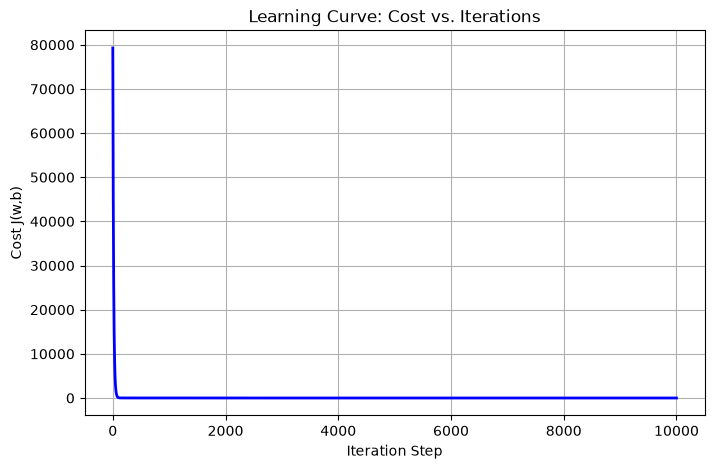

In [13]:
import matplotlib.pyplot as plt

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the J_history data
# We use np.arange to generate an array of numbers from 0 to len(J_history)-1 for the x-axis
ax.plot(np.arange(len(J_history)), J_history, color='blue', linewidth=2)

# Add titles and labels for clarity
ax.set_title("Learning Curve: Cost vs. Iterations")
ax.set_ylabel("Cost J(w,b)")
ax.set_xlabel("Iteration Step")
ax.grid(True)

# Display the graph
plt.show()